# Sentinela Verde — onde estamos, o que falta

**Frente de impacto** · atualizado em 2026-09-10 · apresentação em **17/09**

Este notebook não é uma demo de resultado — para isso veja `02_impacto_score.ipynb`. Aqui é um
**retrato de estado**, para alinhar sem precisar ler três READMEs e um relatório.

1. o que já está medido, e o que sobreviveu a teste
2. o que está rodando agora
3. o que vem depois, com o custo de cada item

## Setup

In [1]:
from pathlib import Path
import sys

def _raiz(p: Path) -> Path:
    for c in [p.resolve(), *p.resolve().parents]:
        if (c / "pyproject.toml").exists():
            return c
    raise RuntimeError("raiz não encontrada")

REPO = _raiz(Path.cwd())
import pandas as pd
from IPython.display import Image, display

RES = REPO / "dados-modelo-impacto" / "raw" / "controles-rf"
OUT = REPO / "modelo-impacto-score" / "outputs"
FIG = REPO / "modelo-impacto-score" / "reports" / "figuras"
pd.set_option("display.max_columns", 40, "display.width", 200)
print("ok")

ok


---
## 1. O achado, em uma linha

Em **18 dos 20** data centers com par válido, o anel de **500 m a 1 km** ao redor — que nunca
contém o empreendimento — converteu para área construída mais do que um terreno pareado sem
data center (p=0,0002). No anel mais interno, com o prédio descontado, são 12 de 16.

Em hectares: o data center mediano tem **1,29 ha**; o excesso convertido fora dele é **~1,2 ha**.
Aproximadamente um hectare a mais se converte ao redor para cada hectare construído.

In [2]:
selos = pd.read_csv(OUT / "selos_de_evidencia.csv")
selos[["eixo", "n_pares", "n_positivo", "p", "excesso_mediano", "selo"]]

,eixo,n_pares,n_positivo,p,excesso_mediano,selo
0,construcao_0_500m,16,12,0.0384,1.490,forte
1,construcao_500m_1km,20,18,0.0002,1.054,forte
2,vegetacao_0_500m,16,11,0.1051,0.517,sugestivo
3,temperatura_0_500m,12,8,0.3877,0.513,nulo_amostra_pequena


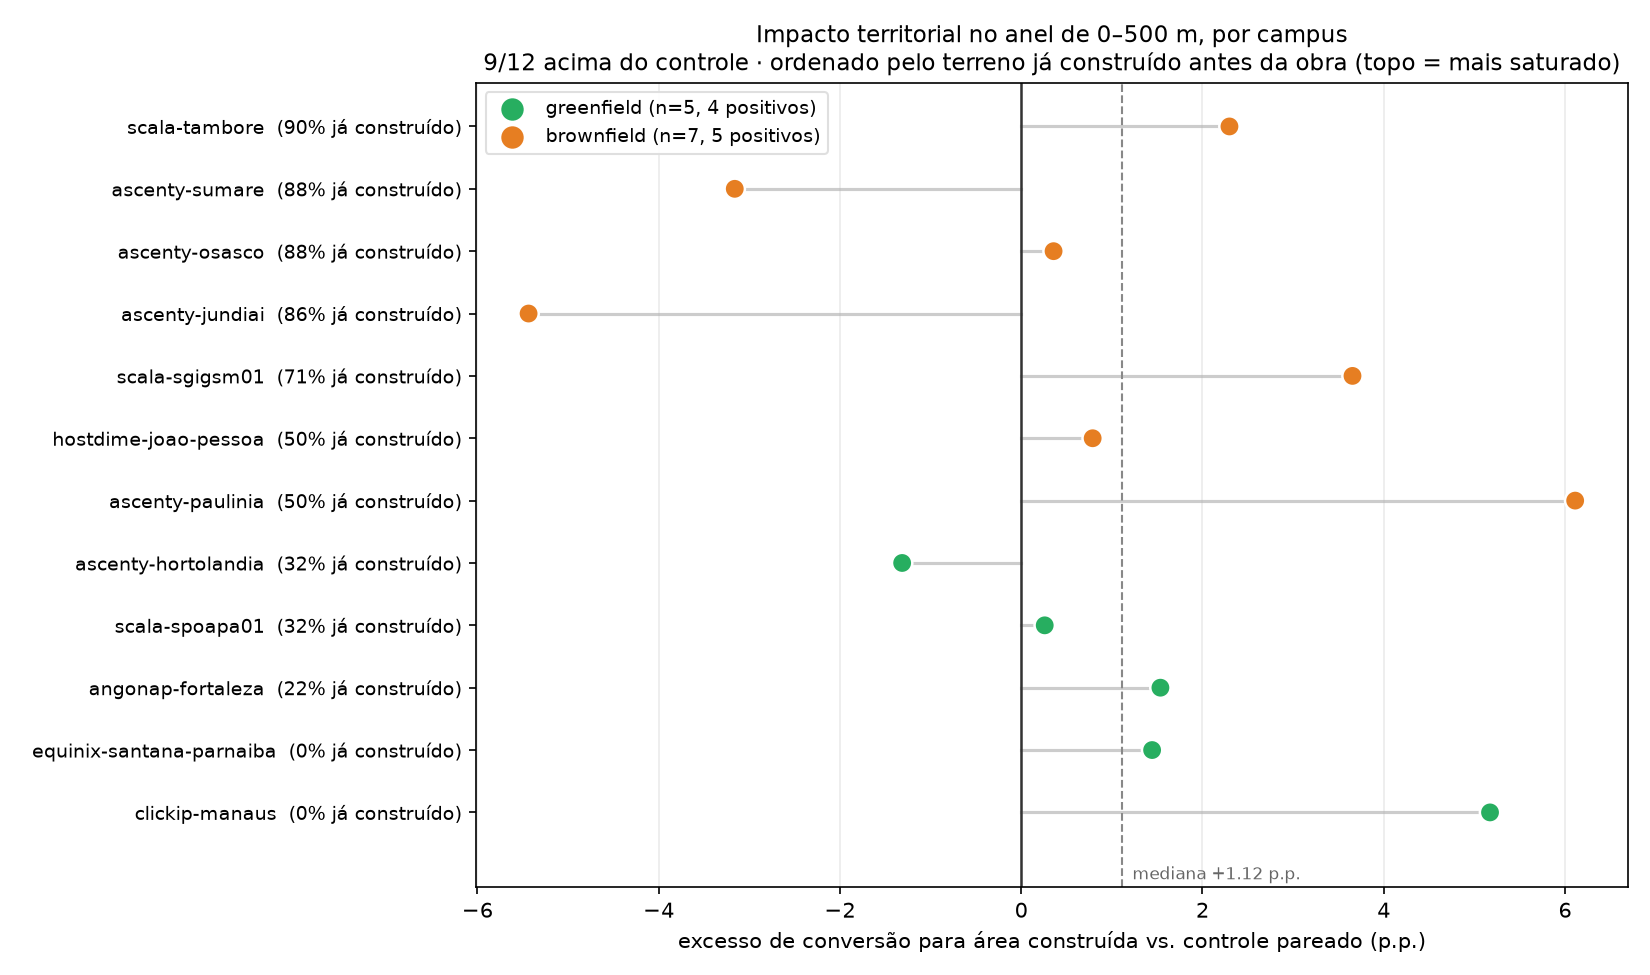

In [3]:
display(Image(filename=str(FIG / "fig_01_boletim.png")))

---
## 2. O que sobreviveu a teste

Esta é a parte que decide se o trabalho vale. **Sete verificações**, e o placar honesto:

In [4]:
placar = pd.DataFrame([
    ("Placebo (controle vs controle)", "o método acha efeito onde nada foi construído?",
     "PASSOU", "8/15, p=0,50 — cai no acaso"),
    ("Tendências pré-obra paralelas", "o DC foi construído onde já adensava?",
     "PASSOU", "6/14, p=0,79"),
    ("Gradiente de distância", "o efeito é local ou regional?",
     "PASSOU", "some em 2 km; densidade cai 7x"),
    ("Circularidade", "o 'efeito' é o próprio prédio?",
     "PASSOU", "+2,06 -> +1,50 pp sem o prédio, mesmo p"),
    ("Reprodução ponta a ponta", "os números saem de novo, iguais?",
     "PASSOU", "21/21 passos, 2x, idênticos"),
    ("Estudo de evento + janela longa", "quando acontece, e persiste?",
     "INCONCLUSIVO", "n=9; os dois anéis apontam para lados opostos"),
    ("Validação cruzada (Dynamic World)", "outro classificador reproduz?",
     "PARCIAL", "direção sim, significância não"),
    ("Amostra expandida (15 -> 20)", "o achado sobrevive a mais casos?",
     "PASSOU, e ficou mais forte", "18/20, p=0,0002 no anel de 0,5-1 km"),
], columns=["verificação", "o que testa", "resultado", "número"])
placar

,verificação,o que testa,resultado,número
0,Placebo (controle vs controle),o método acha efeito onde nada foi construído?,PASSOU,"8/15, p=0,50 — cai no acaso"
1,Tendências pré-obra paralelas,o DC foi construído onde já adensava?,PASSOU,"6/14, p=0,79"
2,Gradiente de distância,o efeito é local ou regional?,PASSOU,some em 2 km; densidade cai 7x
3,Circularidade,o 'efeito' é o próprio prédio?,PASSOU,"+2,06 -> +1,50 pp sem o prédio, mesmo p"
4,Reprodução ponta a ponta,"os números saem de novo, iguais?",PASSOU,"21/21 passos, 2x, idênticos"
5,Estudo de evento + janela longa,"quando acontece, e persiste?",INCONCLUSIVO,n=9; os dois anéis apontam para lados opostos
6,Validação cruzada (Dynamic World),outro classificador reproduz?,PARCIAL,"direção sim, significância não"
7,Amostra expandida (15 -> 20),o achado sobrevive a mais casos?,"PASSOU, e ficou mais forte","18/20, p=0,0002 no anel de 0,5-1 km"


### O placebo é a validação mais forte

Aplicamos o método idêntico a **15 pares de lugares onde nenhum data center foi construído** —
controle contra controle, mesma janela, mesmo ano de obra fictício.

In [5]:
pl = pd.read_csv(RES / "placebo_resumo.csv")
pl = pl[pl.assinatura == "virou_construida"]
for _, r in pl.iterrows():
    print(f"{r.raio_km:>4.1f} km   PLACEBO {int(r.placebo_n_positivo):2d}/{int(r.placebo_n_pares)}"
          f"  p={r.placebo_p_unilateral:.3f}  mediana {r.placebo_excesso_mediano_pp:+6.3f} pp"
          f"      REAL {r.real_frac_positivo:.0%}  p={r.real_p_unilateral:.4f}")

 0.5 km   PLACEBO  8/15  p=0.500  mediana +0.218 pp      REAL 87%  p=0.0037
 1.0 km   PLACEBO  7/15  p=0.696  mediana -0.258 pp      REAL 87%  p=0.0037
 2.0 km   PLACEBO  7/15  p=0.696  mediana -0.365 pp      REAL 60%  p=0.3036


### E a validação cruzada, que é o resultado desconfortável desta semana

Refizemos a medição com o **Google Dynamic World** — outro classificador, outra fonte de treino,
outra equipe, outra resolução (10 m contra 30 m).

In [6]:
dw = pd.read_csv(RES / "dw_comparacao.csv")
dw = dw[dw.assinatura == "virou_construida"].sort_values(["raio_km", "classificador"])
dw[["raio_km", "classificador", "n_positivo", "n_pares", "p_unilateral", "excesso_mediano_pp"]]

,raio_km,classificador,n_positivo,n_pares,p_unilateral,excesso_mediano_pp
0,0.5,dynamic_world,7,10,0.1719,0.9808
1,0.5,rf_v1.0-tuned,9,10,0.0107,1.6662
4,1.0,dynamic_world,6,10,0.3770,0.7832
5,1.0,rf_v1.0-tuned,10,10,0.0010,1.1909
8,2.0,dynamic_world,8,10,0.0547,0.4372
9,2.0,rf_v1.0-tuned,6,10,0.3770,0.6075


**A direção replica; a significância não.** O DW dá excesso positivo nos três raios, com a mesma
ordem de grandeza e o mesmo decaimento com a distância — mas não atinge significância nos raios
onde o nosso classificador é forte.

E a explicação fácil **não** se sustenta. Testamos se o DW seria ruidoso demais para enxergar,
medindo quantos pixels trocam de classe entre anos consecutivos **nos controles**, onde por
construção quase nada mudou — ali, toda troca é ruído:

| instrumento | pixels que trocam de classe por ano, nos controles |
|---|---:|
| Dynamic World | **7,3%** |
| rf_v1.0-tuned (nosso) | **16,8%** |

**O nosso classificador é 2,3× mais instável.** Então não dá para dizer "o DW não enxerga". A
replicação parcial fica registrada como limitação real, e não explicada para longe.

O que segura o achado apesar disso é o **placebo**: ele usou o nosso classificador, com todo esse
ruído, em 15 pares onde nada foi construído — e não achou nada. O ruído não fabrica diferença
entre dois lugares parecidos.

---
## 3. O que ainda não sabemos — e isso vale tanto quanto o resto

In [7]:
nao = pd.DataFrame([
    ("Data da obra", "não pelo modelo",
     "vem de fonte externa; o modelo erra 1,7 a 2,8 anos"),
    ("Impacto no município", "não",
     "todo dado socioeconômico é municipal; um campus é fração ínfima"),
    ("Residencial ou comercial?", "não",
     "OSM tem viés de cobertura: os CONTROLES não são mapeados (0 a 4 feições)"),
    ("População / emprego / PIB", "não",
     "granularidade; o eixo via CNPJ é viável (12/12 CEPs resolvem a logradouro) mas o acesso à base está bloqueado"),
    ("Aquecimento", "estimativa sem confirmação",
     "+0,51 °C no anel com Landsat 30 m, gradiente coerente; precisaria de n=31 e temos 12"),
    ("Magnitude num site novo", "não",
     "13 modelos, todos com R² LOOCV negativo, permutação p=0,77"),
    ("Persistência após 3 anos", "inconclusivo",
     "n=9; anel interno sugere que o controle alcança, o externo sugere o contrário"),
], columns=["pergunta", "resposta", "por quê"])
nao

,pergunta,resposta,por quê
0,Data da obra,não pelo modelo,"vem de fonte externa; o modelo erra 1,7 a 2,8 ..."
1,Impacto no município,não,todo dado socioeconômico é municipal; um campu...
2,Residencial ou comercial?,não,OSM tem viés de cobertura: os CONTROLES não sã...
3,População / emprego / PIB,não,granularidade; o eixo via CNPJ é viável (12/12...
4,Aquecimento,estimativa sem confirmação,"+0,51 °C no anel com Landsat 30 m, gradiente c..."
5,Magnitude num site novo,não,"13 modelos, todos com R² LOOCV negativo, permu..."
6,Persistência após 3 anos,inconclusivo,n=9; anel interno sugere que o controle alcanç...


---
## 4. O que está rodando agora

**Expansão da amostra de 15 para ~25 campi.** Vários resultados não fecham por N, não por ausência
de efeito — temperatura precisaria de n=31, a janela longa é inconclusiva com n=9.

Medimos quantos campi existem de verdade, em vez de estimar:

In [8]:
exp = pd.read_csv(RES / "campi_expansao.csv")
print(f"242 registros do datacentermap -> 118 campi distintos -> {len(exp)} com ano documentado")
print(f"-> {int(exp.elegivel.sum())} ELEGÍVEIS e novos\n")
print("excluídos, por motivo:")
print(exp[~exp.elegivel].motivo_exclusao.value_counts().to_string())
print("\nos novos:")
print(exp[exp.elegivel][["site_id", "municipio", "uf", "ano_inicio_obra"]].to_string(index=False))

242 registros do datacentermap -> 118 campi distintos -> 53 com ano documentado
-> 10 ELEGÍVEIS e novos

excluídos, por motivo:
motivo_exclusao
obra antes de 2016 (sem janela pré no Landsat 8)       22
obra recente demais — ainda não há período pós-obra    15
já é um dos 16 sites validados                          6

os novos:
                           site_id                      municipio                     uf  ano_inicio_obra
                     exp-elea-rjo1                 Rio de Janeiro         Rio de Janeiro             2015
               exp-latitude-sh-sao                      Sao Paulo                     SP             2015
          exp-sitelbra-data-center                       Brasília                     DF             2015
       exp-sky-brasil---jaguariuna                     Jaguariúna                    NaN             2015
                    exp-odata-sp01 Votuparim, Santana de Parnaíba                    NaN             2016
          exp-quantico-data-center 

> **O gargalo não é esforço, é calendário.** 22 campi têm obra antes de 2016 (sem janela pré-obra
> no Landsat 8) e 15 são recentes demais para ter período pós-obra. **O boom brasileiro está
> acontecendo agora.**
>
> Dois dos novos ficam em **Palmas/TO**, região que a amostra atual não cobre — ganho de
> diversidade de bioma, não só de N.

**Ressalva implementada como coluna, não como nota de rodapé:** os 16 sites originais têm
coordenada validada em 5 camadas e ano pesquisado em imprensa. Os 10 novos têm `ano_operacional−1`
como aproximação. A coluna `procedencia` carrega isso, e a análise roda **com e sem** eles.

*Estado:* o pareamento dos controles foi interrompido por queda de rede (`getaddrinfo failed`).
O checkpoint preservou o progresso — é retomável com `--fase controles`.

---
## 5. Os próximos passos, com custo

| # | o quê | por que importa | custo |
|---|---|---|---|
| **1** | Terminar a expansão para ~25 campi | move temperatura e janela longa de "sem N" para testável | ~1 dia |
| **2** | Retreinar o classificador com rótulos do **Dynamic World** | o DW tem classe `bare` NATIVA — é o defeito de origem da nossa classe 3 (F1 0,579), que existe porque o MapBiomas não tem canteiro de obras | ~3 dias |
| **3** | Levantar lista de data centers dos **EUA** com data e coordenada | é onde os números estão: 2018–2022 é o boom americano | depende do acesso |
| **4** | Estudo completo nos EUA | N=100+ resolveria todos os "precisaria de mais casos" | 2–3 semanas |

**Por que o item 2 vem antes do 3.** O Dynamic World é **global**. Retreinar com ele resolve duas
coisas de uma vez: conserta a classe 3 no Brasil **e** remove a dependência do MapBiomas, que só
existe aqui. É o que torna o item 4 possível com o mesmo código.

### O desenho do retreino já está escrito: `docs/decisoes/ADR-006`

Responde as três perguntas de arquitetura, e é o documento a ler antes de aprovar o item 2:

- **um modelo, não dois.** Se cada país tiver o seu, os resultados das duas metades não são
  comparáveis. O risco (aprender *região* em vez de *cobertura*) é controlado tirando
  país/bioma/ecorregião das features e testando **entre países**: treina BR → testa EUA.
- **o teto de amostragem precisa virar por ÁREA**, não por contagem de pixel. É o bug que hoje faz
  a classe 3 ser 2,9% das linhas Landsat contra 17,3% das S2 — e como `sensor` é feature, o modelo
  aprendeu esse prior e o reproduz na saída.
- **o critério de sucesso não é acurácia**, é estabilidade temporal nos controles. O ADR fixa a
  barra em **7,3%** (a do Dynamic World). Se o modelo retreinado não ficar abaixo disso, usar o DW
  direto é a decisão certa — é um critério que pode reprovar a própria proposta.

E um **portão antes do retreino**: medir quantos campi americanos têm data e janela utilizável. O
gargalo dos EUA é provavelmente o mesmo do Brasil (só 53 de 118 campi daqui têm ano). Se forem
menos de ~30 novos, o retreino não se paga.

**O bloqueio do eixo econômico**, para quem puder destravar: a base CNPJ da Receita migrou para um
portal Nextcloud sem listagem HTTP (404), `dadosabertos.rfb.gov.br` não responde, e a API do
`dados.gov.br` passou a exigir chave (401). Resolve com **uma** das duas: a URL atual de um
compartilhamento da RFB, ou uma chave da API. O desenho já está pronto e o teste de granularidade
já passou.

---
## 6. Como conferir tudo

```bash
python scripts/reproduzir_impacto.py --listar          # os 31 passos, com custo e dependência
python scripts/reproduzir_impacto.py                   # 21 passos offline, ~3 min
python scripts/reproduzir_impacto.py --etapa completo  # + 10 passos de rede
```

Rodado duas vezes, saídas idênticas até a quarta casa decimal.

| documento | para quem |
|---|---|
| `modelo-impacto-score/reports/sumario-executivo.md` | banca — 1 página, sem p-valores |
| `modelo-impacto-score/reports/relatorio-impacto.md` | técnico, com todos os números e limitações |
| **`notebooks/04_demo_visual_classificador.ipynb`** | **o modelo funcionando, com imagem de satélite** |
| `notebooks/02_impacto_score.ipynb` | demo executada do modelo de impacto |
| `notebooks/01_modelo_impacto.ipynb` | o desenho de pareamento, passo a passo |
| `docs/decisoes/ADR-006-*.md` | o desenho do classificador global BR+EUA |

**Para começar por algo visual**, o `04` é o caminho: mostra a imagem crua, a mesma cena em
falsa-cor e a classificação lado a lado, a série ano a ano, o mapa de confiança do modelo e os
anéis onde o impacto é medido. Tem uma célula interativa que renderiza qualquer site e ano na hora.